<a href="https://colab.research.google.com/github/Aswathi281099/Natural-Language-Processing-/blob/main/Project_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from textblob import TextBlob
from collections import Counter

In [14]:
df = pd.read_csv("1429_1.csv", low_memory=False)

# Keep only review text
df = df[['reviews.text']]

# Remove missing values
df.dropna(inplace=True)

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (34659, 1)
                                        reviews.text
0  This product so far has not disappointed. My c...
1  great for beginner or experienced person. Boug...
2  Inexpensive tablet for him to use and learn on...
3  I've had my Fire HD 8 two weeks now and I love...
4  I bought this for my grand daughter when she c...


In [15]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):

    text = str(text).lower()

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = text.split()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

df['cleaned_review'] = df['reviews.text'].apply(preprocess)

print("\nCleaned Reviews")
print(df[['reviews.text', 'cleaned_review']].head())



Cleaned Reviews
                                        reviews.text  \
0  This product so far has not disappointed. My c...   
1  great for beginner or experienced person. Boug...   
2  Inexpensive tablet for him to use and learn on...   
3  I've had my Fire HD 8 two weeks now and I love...   
4  I bought this for my grand daughter when she c...   

                                      cleaned_review  
0  product far disappointed child love use like a...  
1  great beginner experienced person bought gift ...  
2  inexpensive tablet use learn step nabi thrille...  
3  ive fire hd two week love tablet great valuewe...  
4  bought grand daughter come visit set user ente...  


In [16]:
def sentiment(text):

    polarity = TextBlob(text).sentiment.polarity

    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

df['sentiment'] = df['cleaned_review'].apply(sentiment)

print("\nSentiment Counts:")
print(df['sentiment'].value_counts())


Sentiment Counts:
sentiment
Positive    31249
Neutral      1849
Negative     1561
Name: count, dtype: int64


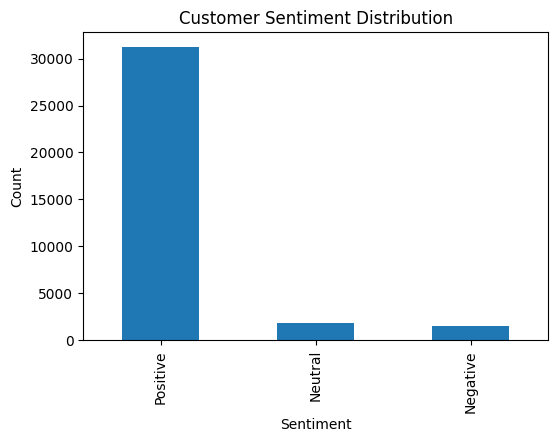

In [17]:
plt.figure(figsize=(6,4))
df['sentiment'].value_counts().plot(kind='bar')
plt.title("Customer Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [18]:
negative_reviews = df[df['sentiment'] == 'Negative']

all_words = " ".join(
    negative_reviews['cleaned_review']
).split()

word_freq = Counter(all_words)

print("\nTop Improvement Areas:")

for word, count in word_freq.most_common(20):
    print(word, ":", count)


Top Improvement Areas:
tablet : 451
game : 348
amazon : 284
use : 274
bought : 265
get : 243
one : 239
like : 237
fire : 222
work : 207
play : 192
kindle : 182
little : 179
tv : 168
time : 165
would : 159
price : 146
well : 138
screen : 128
apps : 128


In [19]:
positive = len(df[df['sentiment'] == 'Positive'])
negative = len(df[df['sentiment'] == 'Negative'])
neutral = len(df[df['sentiment'] == 'Neutral'])

print("\n" + "="*50)
print("BUSINESS INSIGHTS")
print("="*50)

print("Positive Reviews :", positive)
print("Negative Reviews :", negative)
print("Neutral Reviews  :", neutral)

print("\nMost Common Issues:")

for word, count in word_freq.most_common(10):
    print(f"{word} ({count} mentions)")

print("\nRecommendations:")
print("- Improve areas frequently appearing in negative reviews.")
print("- Focus on product quality and usability issues.")
print("- Investigate recurring customer complaints.")
print("- Enhance customer satisfaction through targeted improvements.")


BUSINESS INSIGHTS
Positive Reviews : 31249
Negative Reviews : 1561
Neutral Reviews  : 1849

Most Common Issues:
tablet (451 mentions)
game (348 mentions)
amazon (284 mentions)
use (274 mentions)
bought (265 mentions)
get (243 mentions)
one (239 mentions)
like (237 mentions)
fire (222 mentions)
work (207 mentions)

Recommendations:
- Improve areas frequently appearing in negative reviews.
- Focus on product quality and usability issues.
- Investigate recurring customer complaints.
- Enhance customer satisfaction through targeted improvements.
